## INTRODUCTION

Throughout this notebook, we will analyze and compare several baseline classification models by manually tuning their hyperparameters and decision thresholds. The goal is to understand how adjusting these parameters impacts the results observed in the confusion matrix, making this a useful first approach to model development in classification problems.

The following methods will be evaluated:

* KNN
* Logistic Regression
* SVM (RBF kernel)
* Linear SVM
* Polynomial SVM
* Decision Trees
* Random Forest
* Gradient Boosting Classifier
* Naive Bayes

The analysis concludes with a comparison of the different models to better understand their behavior and performance.

## Import Libraries and Read DataFrame

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score,precision_score, recall_score,f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC,LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import kagglehub
import os


In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

Path to dataset files: C:\Users\mar_c\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


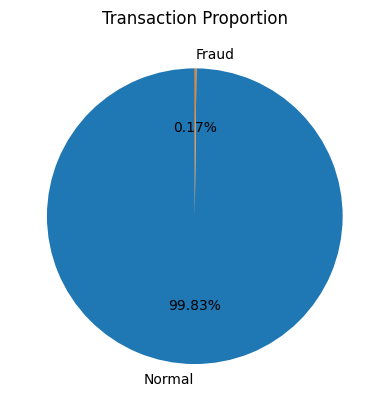

In [5]:

counts = df['Class'].value_counts()

plt.figure()
plt.pie(
    counts.values,
    labels=['Normal', 'Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Transaction Proportion")
plt.show()

# EDA

In [6]:
## Data description
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


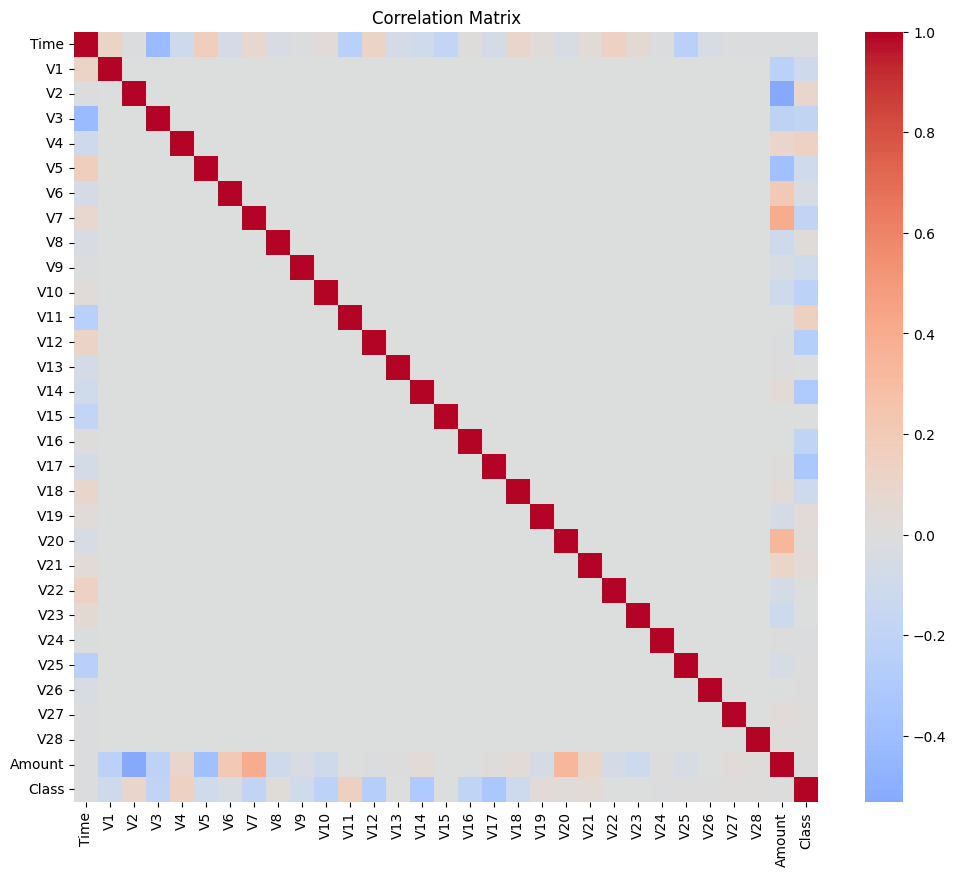

In [7]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [8]:
corr_target = df.corr()['Class'].sort_values(ascending=False)
corr_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

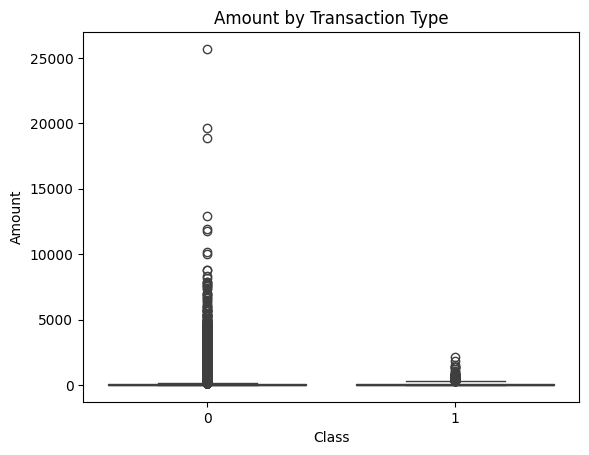

In [9]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Amount by Transaction Type")
plt.show()

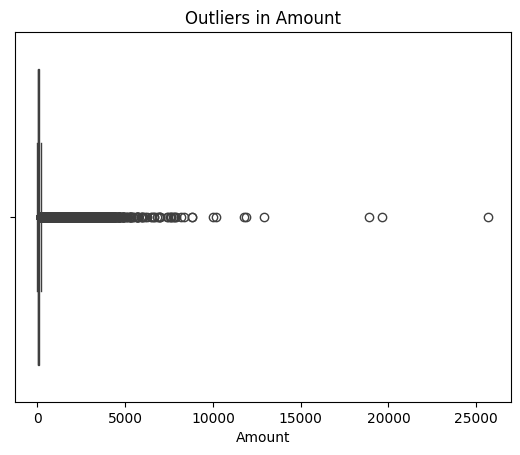

In [10]:
## Inspect outliers in Amount

sns.boxplot(x=df['Amount'])
plt.title("Outliers in Amount")
plt.show()

In [11]:
## Missing values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
## Class proportion
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

<Axes: xlabel='Amount', ylabel='Count'>

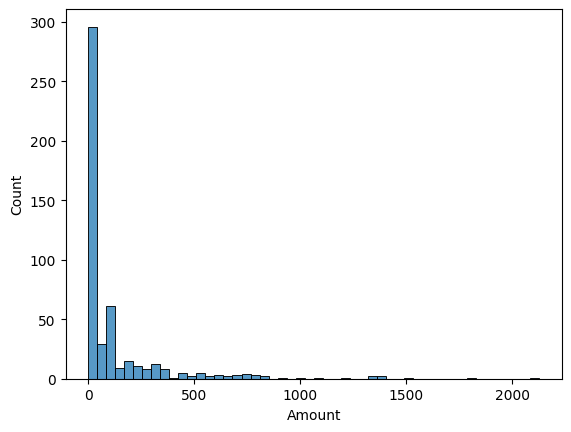

In [13]:
## Amount distribution for fraudulent transactions
sns.histplot(data=df[df.Class==1], x="Amount", bins=50)

# Train/Test Split and Normalization

In [14]:

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)  # all variables except the label
y = df['Class']               # target variable (fraud or not)


# Split into train and test

# stratify=y ensures the class imbalance (fraud vs normal)
# remains the same in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Define which columns will be scaled

# We only scale Amount and Time because:
# - V1–V28 are already transformed (PCA)
columns_to_scale = ['Amount', 'Time']


# Create transformer
# ColumnTransformer allows applying transformations
# only to certain columns while leaving the rest unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), columns_to_scale)  # scales only these columns
    ],
    remainder='passthrough'  # leaves the rest unchanged (V1–V28)
)

# Fit the scaler ONLY on the training set

# fit_transform learns the mean and std from the training set
# and transforms the data (prevents data leakage)
X_train_prepared = preprocessor.fit_transform(X_train)

# Transform test WITHOUT refitting
# only applies the same transformation learned from the training set
X_test_prepared = preprocessor.transform(X_test)

# Classification Models to Train

## K-Nearest Neighbors

Searching for the best hyperparameters manually, being k and treshold

In [ ]:
# # Use the training dataset
# X_data = X_train_prepared
# y_data = y_train

# # Define hyperparameters
# lista_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]
# lista_thresholds = np.arange(0.05, 0.55, 0.05)

# # Stratified cross-validation, creates different splits for training and validation
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# # Results
# resultados = []

# # Search for K + threshold
# for k in lista_k:
    
# #Lists to store the best result obtained in each fold
# #for the current value of n_neighbors
#     recalls_folds = []
#     precisions_folds = []
#     thresholds_folds = []
    
# cv.split(...) generates the train and validation indices
# #for each fold, preserving the class distribution
#     for train_idx, val_idx in cv.split(X_data, y_data):
        
# #The subsets for the current fold are created:
# #one part for training and another for cross-validation
#         X_fold_train = X_data[train_idx]
#         X_fold_val = X_data[val_idx]
#         y_fold_train = y_data.iloc[train_idx]
#         y_fold_val = y_data.iloc[val_idx]
        
# #The KNN model is instantiated with the current value of k
# #n_jobs=-1 allows using all available CPU cores
# #to speed up neighbor computation
#         modelo_knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        
#         # The model "learns" by storing the patterns from the training fold;
#         # in KNN no coefficients are fitted, instead the training set is stored
#         # to compute distances during prediction
#         modelo_knn.fit(X_fold_train, y_fold_train)
        
#         # The estimated probabilities for the positive class (fraud) are obtained
#         # [:, 1] selects only the probability of belonging to class 1
#         y_proba_val = modelo_knn.predict_proba(X_fold_val)[:, 1]
        
#         # Variables to store the best combination within this fold:
#         # the goal is to find the threshold that maximizes recall while ensuring precision >= 0.80
#         mejor_recall_fold = -1
#         mejor_precision_fold = 0
#         mejor_threshold_fold = None
        
#         # Different cutoff thresholds are tested on the predicted probabilities;
#         # this converts probabilities into binary classes
#         for threshold in lista_thresholds:
#             y_pred_val = (y_proba_val >= threshold).astype(int)
            
#             # Precision: among the cases predicted as fraud,
#             # how many were actually fraud
#             precision = precision_score(y_fold_val, y_pred_val, zero_division=0)
            
#             # Recall: among all actual fraud cases,
#             # how many the model was able to detect
#             recall = recall_score(y_fold_val, y_pred_val, zero_division=0)
            
#             # Business/modeling constraint:
#             # only thresholds with precision of at least 0.80 are considered
#             if precision >= 0.80:
                
#                 # Among the valid thresholds, the one that produces
#                 # the highest recall in this fold is kept
#                 if recall > mejor_recall_fold:
#                     mejor_recall_fold = recall
#                     mejor_precision_fold = precision
#                     mejor_threshold_fold = threshold
        
#         # If no threshold met the minimum precision constraint,
#         # 0 is stored as the fold result and None for the threshold
#         if mejor_recall_fold == -1:
#             recalls_folds.append(0)
#             precisions_folds.append(0)
#             thresholds_folds.append(None)
#         else:
#             # If a valid threshold was found, the best result
#             # obtained in this fold is stored
#             recalls_folds.append(mejor_recall_fold)
#             precisions_folds.append(mejor_precision_fold)
#             thresholds_folds.append(mejor_threshold_fold)
    
#     # Only valid thresholds (different from None) are filtered
#     # to compute a representative average
#     thresholds_validos = [t for t in thresholds_folds if t is not None]
    
#     # The average performance for this value of k is summarized
#     # across all cross-validation folds
#     resultados.append({
#         'n_neighbors': k,
#         'recall_promedio_cv': np.mean(recalls_folds),
#         'precision_promedio_cv': np.mean(precisions_folds),
#         'threshold_promedio_cv': np.mean(thresholds_validos) if len(thresholds_validos) > 0 else None
#     })
    
#     recalls_folds = []
#     precisions_folds = []
#     thresholds_folds = []
    
# # Results
# df_knn_results = pd.DataFrame(results).sort_values(
#     by='recall_promedio_cv',
#     ascending=False
# ).reset_index(drop=True)

# print(df_resultados_knn)

Final Model with the chosen Hyperparameters

In [16]:
# Create the final model with the chosen hyperparameters
modelo_knn_final = KNeighborsClassifier(
    n_neighbors=11,
    n_jobs=-1
)

# Train the model on the FULL training set
modelo_knn_final.fit(X_train_prepared, y_train)

# Get probabilities on the test set
y_proba_knn_final = modelo_knn_final.predict_proba(X_test_prepared)[:, 1]

# Apply the chosen threshold
# The lower the threshold, the more cases are classified as fraud (recall increases, precision decreases)
threshold_final = 0.10
y_pred_knn_final = (y_proba_knn_final >= threshold_final).astype(int)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_final))

# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn_final, digits=4))

# ROC-AUC should be above 0.5; closer to 1 is better; measures the ability to separate classes
roc_auc_knn_final = roc_auc_score(y_test, y_proba_knn_final)
print("\nROC-AUC:", round(roc_auc_knn_final, 4))

# PR-AUC measures how well the model detects the positive class (fraud) without increasing false positives
pr_auc_knn_final = average_precision_score(y_test, y_proba_knn_final)
print("PR-AUC:", round(pr_auc_knn_final, 4))

Confusion Matrix:
[[56843    21]
 [   12    86]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.8037    0.8776    0.8390        98

    accuracy                         0.9994     56962
   macro avg     0.9018    0.9386    0.9194     56962
weighted avg     0.9995    0.9994    0.9994     56962


ROC-AUC: 0.9488
PR-AUC: 0.8308


## Logistic Regression

Searching for the best hyperparameters,only value of C in this case

In [17]:
# model_results = []

# # Values of hyperparameter C to evaluate
# # C controls regularization:
# # small values -> stronger regularization (simpler model)
# # large values -> weaker regularization (more flexible model)
# valores_C = [0.01, 0.1, 1, 10, 100]

# for c in valores_C:

#     # Definition of the logistic regression model
#     modelo = LogisticRegression(
#         C=c,
#         penalty='l2',          # L2 regularization (penalizes large coefficients)
#         solver='liblinear',    # Suitable solver for small/medium and binary datasets
#         class_weight=None,     # Does not adjust weights for class imbalance
#         max_iter=1000,         # Maximum number of iterations for convergence
#         random_state=42
#     )

#     # Train the model using the entire training set
#     # Here the coefficients (betas) that minimize the loss function are estimated
#     modelo.fit(X_train_prepared, y_train)

#     # Obtain probabilities for the positive class (fraud)
#     # The logistic model is used: sigmoid(Xβ)
#     probs = modelo.predict_proba(X_test_prepared)[:, 1]

#     # Apply a fixed threshold (0.02) to convert probabilities into classes
#     # Low threshold -> increases recall, decreases precision
#     preds = (probs >= 0.02).astype(int)

#     # Confusion matrix components:
#     # tn: true negatives
#     # fp: false positives
#     # fn: false negatives
#     # tp: true positives
#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     # Recall (sensitivity):
#     # proportion of fraud cases correctly detected
#     recall = tp / (tp + fn)

#     # False Positive Rate (FPR):
#     # proportion of non-fraud cases incorrectly classified as fraud
#     fpr = fp / (fp + tn)

#     # Store results for this value of C
#     model_results.append({
#         "C": c,
#         "recall": recall,
#         "fpr": fpr,
#         "TP": tp,
#         "FP": fp,
#         "FN": fn,
#         "TN": tn
#     })

# # Convert to DataFrame for comparative analysis
# df_modelos = pd.DataFrame(model_results)

# # Sort models by recall in descending order
# # Priority: maximize fraud detection
# df_modelos = df_modelos.sort_values(
#     by="recall",
#     ascending=False
# ).reset_index(drop=True)

# print(df_modelos)

Searching for the best treshold

In [18]:
# # 1. Define model for threshold search
# modelo_lr_final = LogisticRegression(
#     C=0.10,
#     penalty='l2',
#     solver='liblinear',
#     class_weight=None,
#     max_iter=1000,
#     random_state=42
# )

# # 2. Train on the FULL training set
# modelo_lr_final.fit(X_train_prepared, y_train)

# # 3. Get probabilities on test
# probabilidades_test = modelo_lr_final.predict_proba(X_test_prepared)[:, 1]

# # 4. Test multiple thresholds
# thresholds = np.arange(0.01, 0.06, 0.005)

# resultados_threshold = []

# for threshold in thresholds:
#     predicciones_test = (probabilidades_test >= threshold).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

#     recall = tp / (tp + fn)
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     fpr = fp / (fp + tn)

#     resultados_threshold.append({
#         "threshold": threshold,
#         "TN": tn,
#         "FP": fp,
#         "FN": fn,
#         "TP": tp,
#         "recall": recall,
#         "precision": precision,
#         "fpr": fpr
#     })

# df_thresholds_final = pd.DataFrame(resultados_threshold)

# print(df_thresholds_final)

Creating the final model with the hyperparameters

In [19]:
# Define the final logistic regression model with the selected hyperparameters
modelo_lr_final = LogisticRegression(
    C=0.10,                 # Inverse of regularization: low value -> stronger penalty (simpler model)
    penalty='l2',           # L2 regularization: prevents large coefficients (overfitting control)
    solver='liblinear',     # Optimization algorithm suitable for binary problems
    class_weight=None,      # Weights not adjusted for imbalance (could use 'balanced')
    max_iter=1000,          # Maximum number of iterations to ensure convergence
    random_state=42
)

# Train on the FULL training set
modelo_lr_final.fit(X_train_prepared, y_train)

# Get probabilities for the positive class (fraud)
probabilidades_test_lr = modelo_lr_final.predict_proba(X_test_prepared)[:, 1]

# Apply the final threshold to convert probabilities into binary classes
# Low threshold (0.025) -> favors high recall at the cost of precision
threshold_final = 0.025
probabilidades_test_lr = (probabilidades_test_lr >= threshold_final).astype(int)

# Build the confusion matrix
confusion_mat = confusion_matrix(y_test, probabilidades_test_lr)
tn, fp, fn, tp = confusion_mat.ravel()

# Recall (sensitivity):
# proportion of actual frauds correctly detected
recall = tp / (tp + fn)

# Precision:
# proportion of fraud predictions that are actually fraud
# Protected against division by zero
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# False Positive Rate (FPR):
# proportion of non-frauds incorrectly classified as fraud
fpr = fp / (fp + tn)

# Classification report:
classification_rep = classification_report(y_test, probabilidades_test_lr, zero_division=0)

print("Confusion Matrix:")
print(confusion_mat)

print("\nKey Metrics:")
print(f"FPR: {fpr:.6f}")

print("\nClassification Report:")
print(classification_rep)

Confusion Matrix:
[[56806    58]
 [   12    86]]

Key Metrics:
FPR: 0.001020

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## SVM RBF

Looking for hyperpamaters, like C and Gamma

In [21]:
# # A stratified sample is taken from the training set to reduce computational cost while preserving class proportions
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.1,
#     stratify=y_train,
#     random_state=42
# )

# # Define the hyperparameter search space for C (regularization) and gamma (influence of each point in RBF)
# valores_C = [0.1, 1, 10]
# valores_gamma = ['scale', 0.01, 0.1, 1]

# # Threshold applied on the decision_function; in SVM the value 0 represents the natural decision boundary
# threshold = 0.0

# resultados = []

# # Iterate over all combinations of C and gamma (manual grid search)
# for c in valores_C:
#     for g in valores_gamma:

#         # Definition of the SVM model with RBF kernel; probability=False avoids the costly computation of probabilities
#         modelo = SVC(
#             kernel='rbf',
#             C=c,
#             gamma=g,
#             probability=False,
#             random_state=42
#         )

#         # Train the model; SVM finds the optimal hyperplane by maximizing the margin
#         modelo.fit(X_train_sample, y_train_sample)

#         # decision_function returns the distance to the hyperplane; positive values indicate class 1
#         scores = modelo.decision_function(X_test_prepared)

#         # Apply the threshold to the scores to convert them into binary classes
#         preds = (scores >= threshold).astype(int)

#         # Decompose the confusion matrix into its components
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         # Precision measures the proportion of predicted positives that are correct
#         precision = precision_score(y_test, preds, zero_division=0)

#         # Recall measures the proportion of actual positives that were detected
#         recall = recall_score(y_test, preds, zero_division=0)

#         # F1-score balances precision and recall using the harmonic mean
#         f1 = f1_score(y_test, preds, zero_division=0)

#         # False Positive Rate measures the proportion of negatives incorrectly classified as positives
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         # Store metrics and confusion matrix components for comparative analysis
#         resultados.append({
#             "C": c,
#             "gamma": g,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# # Convert results to a DataFrame for easier analysis
# df_resultados_svc_rbf = pd.DataFrame(resultados)

# # Sort prioritizing recall then precision to favor fraud detection
# df_resultados_svc_rbf = df_resultados_svc_rbf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_svc_rbf)

Looking to find the optimal treshold

In [22]:
# ## Find the optimal threshold

# # --------------------------------------------------------
# # 1. Train the final model with the best hyperparameters
# # --------------------------------------------------------
# modelo_final = SVC(
#     kernel='rbf',
#     C=10,
#     gamma=0.01,
#     probability=False,
#     random_state=42
# )

# modelo_final.fit(X_train_sample, y_train_sample)

# # --------------------------------------------------------
# # 2. Get scores
# # --------------------------------------------------------
# scores = modelo_final.decision_function(X_test_prepared)

# # --------------------------------------------------------
# # 3. Test different thresholds
# # --------------------------------------------------------
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados_threshold = []

# for t in thresholds:
#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados_threshold.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 4. Create a DataFrame with the results
# # --------------------------------------------------------
# df_thresholds = pd.DataFrame(resultados_threshold)

# # --------------------------------------------------------
# # 5. Filter thresholds with FPR below 5%
# # --------------------------------------------------------
# df_fpr_menor_5 = df_thresholds[df_thresholds["fpr"] < 0.01].copy()

# # --------------------------------------------------------
# # 6. Choose the best:
# #    first highest recall, then highest precision
# # --------------------------------------------------------
# df_fpr_menor_5 = df_fpr_menor_5.sort_values(
#     by=["fpr",],
#     ascending=[False]
# ).reset_index(drop=True)

# df_fpr_menor_5

Final model with found hyperparameters

In [23]:
# 1. Final SVC model with RBF kernel
modelo_svc_rbf_final = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    probability=False,
    random_state=42
)

# Train on the FULL training set
modelo_svc_rbf_final.fit(X_train_prepared, y_train)

# Scores and predictions on the test set
scores_final_rbf = modelo_svc_rbf_final.decision_function(X_test_prepared)

# In SVM the threshold can be negative because it is not calibrated as probabilities
threshold_final = -0.72
preds_final = (scores_final_rbf >= threshold_final).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# Results
print("Threshold final:", threshold_final)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification Report:")
print(classification_report(y_test, preds_final))

print("\nMetrics Summary:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"FPR:       {fpr:.4%}")

Threshold final: -0.72

Confusion Matrix:
[[56850    14]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.87      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Metrics Summary:
Precision: 0.8586
Recall:    0.8673
F1-score:  0.8629
FPR:       0.0246%


## Linear SVM

Sample to make wait time shorter

In [24]:
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_prepared,
    y_train,
    train_size=0.2,        # use 20%
    stratify=y_train,
    random_state=42
)

Looking for hyperparameters, using class_weight='balanced' due to imbalanced data

In [26]:
# # Define the values of hyperparameter C that controls regularization of the linear model
# valores_C = [0.01, 0.1, 1, 10, 100]

# # Use class_weight='balanced' to automatically adjust weights inversely proportional to class frequency
# class_weights = ['balanced']

# # Threshold applied on decision_function; in linear models the value 0 is the decision boundary
# threshold = 0.0

# resultados = []

# for cw in class_weights:
#     for c in valores_C:

#         modelo = LinearSVC(
#             C=c,                  
#             class_weight=cw,      
#             dual=False,           # Uses the primal formulation (more efficient when n_samples > n_features)
#             max_iter=5000,        # Increases the number of iterations to ensure convergence
#             random_state=42
#         )

#         # Train the model; the margin is optimized by maximizing separation between classes
#         modelo.fit(X_train_prepared, y_train)

#         # decision_function returns the distance to the hyperplane; positive values indicate class 1
#         scores = modelo.decision_function(X_test_prepared)

#         # Convert scores to binary classes using the defined threshold
#         preds = (scores >= threshold).astype(int)

#         # Extract components of the confusion matrix
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         # Precision measures the proportion of predicted positives that are correct
#         precision = precision_score(y_test, preds, zero_division=0)

#         # Recall measures the proportion of actual positives correctly detected
#         recall = recall_score(y_test, preds, zero_division=0)

#         # F1-score combines precision and recall into a single balanced metric
#         f1 = f1_score(y_test, preds, zero_division=0)

#         # FPR measures the proportion of negatives incorrectly classified as positives
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados.append({
#             "C": c,
#             "class_weight": cw,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# df_resultados_linearsvc = pd.DataFrame(resultados)

# df_resultados_linearsvc = df_resultados_linearsvc.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_linearsvc)

Loooking for optimal threshold

In [ ]:
# # 1. Train model with C = 1 and search for the optimal threshold
# modelo_linearsvc_final = LinearSVC(
#     C=1,
#     class_weight='balanced',
#     dual=False,
#     max_iter=5000,
#     random_state=42
# )

# modelo_linearsvc_final.fit(X_train_prepared, y_train)

# # 2. Get scores
# scores = modelo_linearsvc_final.decision_function(X_test_prepared)

# # 3. Test different thresholds
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados_threshold = []

# for t in thresholds:
#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados_threshold.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp,
#         "matriz_confusion": [[tn, fp], [fn, tp]]
#     })

# # 4. Final DataFrame
# df_thresholds_linearsvc = pd.DataFrame(resultados_threshold)

# df_thresholds_linearsvc = df_thresholds_linearsvc.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# df_thresholds_linearsvc_fpr_5 = df_thresholds_linearsvc[
#     df_thresholds_linearsvc["fpr"] < 0.05
# ].copy()

# df_thresholds_linearsvc_fpr_5 = df_thresholds_linearsvc_fpr_5.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_thresholds_linearsvc_fpr_5.head(10))

Final model with hyperparameters 

In [28]:
# 1. Final model
modelo_linearsvc_final = LinearSVC(
    C=1,
    class_weight='balanced',
    dual=False,
    max_iter=5000,
    random_state=42
)

# 2. Train on the FULL training set
modelo_linearsvc_final.fit(X_train_prepared, y_train)

# 3. Scores and predictions
scores_final_lineal = modelo_linearsvc_final.decision_function(X_test_prepared)

threshold_final = 0.90
preds_final = (scores_final_lineal >= threshold_final).astype(int)

# 4. Metrics
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# 5. Results
print("Threshold final:", threshold_final)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification Report:")
print(classification_report(y_test, preds_final))

print("\nMetrics Summary:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"FPR:       {fpr:.4%}")

Threshold final: 0.9

Confusion Matrix:
[[56760   104]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.89      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962


Metrics Summary:
Precision: 0.4555
Recall:    0.8878
F1-score:  0.6021
FPR:       0.1829%


## Polynomial SVM

Search of hyperparameters, with sample to reduce wait time

In [30]:
# # Take a stratified sample from the training set
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.2,
#     stratify=y_train,
#     random_state=42
# )

# valores_C = [0.1, 1, 10]
# valores_degree = [2,3,4,5]  # degree=1 would be equivalent to a linear kernel

# threshold = 0.0

# resultados = []

# for c in valores_C:
#     for d in valores_degree:

#         # Definition of the SVM model with polynomial kernel; transforms the space into higher dimensions
#         modelo = SVC(
#             kernel='poly',
#             C=c,              
#             degree=d,         # Polynomial degree; higher degree -> greater capacity to model non-linear relationships
#             gamma='scale',    # Automatic scaling factor based on the number of features
#             coef0=0,          # Independent term of the polynomial kernel; affects model curvature
#             probability=False, # Avoids probability computation to reduce computational cost
#             random_state=42
#         )

#         # Train the model; the margin is optimized in the transformed feature space
#         modelo.fit(X_train_sample, y_train_sample)

#         # decision_function returns the distance to the hyperplane in the transformed space
#         scores = modelo.decision_function(X_test_prepared)

#         # Convert scores into binary classes using the defined threshold
#         preds = (scores >= threshold).astype(int)

#         # Decompose the confusion matrix into its basic components
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         precision = precision_score(y_test, preds, zero_division=0)

#         recall = recall_score(y_test, preds, zero_division=0)

#         f1 = f1_score(y_test, preds, zero_division=0)

#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados.append({
#             "C": c,
#             "degree": d,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# df_resultados_poly = pd.DataFrame(resultados)

# df_resultados_poly = df_resultados_poly.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_poly)

Tresholds tests, and False Positive Ratio Filter

In [31]:

# # Final model with the best hyperparameters
# modelo_poly_final = SVC(
#     kernel='poly',
#     C=0.1,
#     degree=2,
#     gamma='scale',
#     coef0=0,
#     probability=False,
#     random_state=42
# )

# modelo_poly_final.fit(X_train_prepared, y_train)

# # Get scores
# scores = modelo_poly_final.decision_function(X_test_prepared)

# # Test thresholds
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados = []

# for t in thresholds:

#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # DataFrame
# df_thresholds_poly = pd.DataFrame(resultados)

# # Filter by FPR < 5%
# df_validos = df_thresholds_poly[df_thresholds_poly["fpr"] < 0.05].copy()

# # sort by best recall and precision
# df_validos = df_validos.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_validos.head(10))

# # Best threshold
# mejor_threshold = df_validos.loc[0, "threshold"]

# print("\nBest threshold:", mejor_threshold)

Final Model

In [32]:
# 1. Final polynomial SVM model
modelo_svc_poly_final = SVC(
    kernel='poly',
    C=0.1,
    degree=2,  ## Degree of 1 would be linear
    gamma='scale',  # Automatic scaling factor based on the number of features
    coef0=0,  # Independent term of the polynomial kernel; affects model curvature
    probability=False,
    random_state=42
)

# 2. Train on the full training set
modelo_svc_poly_final.fit(X_train_prepared, y_train)

# 3. Scores and predictions
scores_final_poly = modelo_svc_poly_final.decision_function(X_test_prepared)

# In SVM the threshold can be negative because it is not calibrated as probabilities
threshold_final = -0.5
preds_final = (scores_final_poly >= threshold_final).astype(int)

# 4. Metrics
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification Report:")
print(classification_report(y_test, preds_final))

print("\nMetrics Summary:")
print(f"FPR:       {fpr:.4%}")


Confusion Matrix:
[[56851    13]
 [   22    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.78      0.81        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Metrics Summary:
FPR:       0.0229%


## Decision Trees

Hyperparameters for Decision trees

In [34]:
# # Define the hyperparameter space to control tree complexity and regularization
# param_grid = {
#     "max_depth": [3, 5, 10, 15, None],                 # Maximum tree depth; None allows unrestricted growth
#     "min_samples_leaf": [1, 5, 10, 20],                # Minimum samples per leaf to avoid overly specific nodes
#     "min_samples_split": [2, 10, 20],                  # Minimum samples required to split a node
#     "class_weight": [None, "balanced"]                 # Weight adjustment to handle class imbalance
# }

# resultados = []

# for max_depth in param_grid["max_depth"]:
#     for min_samples_leaf in param_grid["min_samples_leaf"]:
#         for min_samples_split in param_grid["min_samples_split"]:
#             for class_weight in param_grid["class_weight"]:

#                 # Definition of the Decision Tree model with specific hyperparameters
#                 modelo = DecisionTreeClassifier(
#                     max_depth=max_depth,
#                     min_samples_leaf=min_samples_leaf,
#                     min_samples_split=min_samples_split,
#                     class_weight=class_weight,
#                     random_state=42
#                 )

#                 # Train the model; the tree learns recursive decision rules to separate classes
#                 modelo.fit(X_train_prepared, y_train)

#                 # Obtain probabilities for the positive class based on proportions in leaf nodes
#                 probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]

#                 # Apply a fixed threshold to convert probabilities into binary classes
#                 threshold = 0.5
#                 predicciones = (probabilidades >= threshold).astype(int)

#                 # Extract components of the confusion matrix
#                 tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#                 recall = tp / (tp + fn) if (tp + fn) > 0 else 0

#                 precision = tp / (tp + fp) if (tp + fp) > 0 else 0

#                 fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#                 resultados.append({
#                     "max_depth": max_depth,
#                     "min_samples_leaf": min_samples_leaf,
#                     "min_samples_split": min_samples_split,
#                     "class_weight": class_weight,
#                     "recall": recall,
#                     "precision": precision,
#                     "fpr": fpr,
#                     "tn": tn,
#                     "fp": fp,
#                     "fn": fn,
#                     "tp": tp
#                 })

# df_resultados = pd.DataFrame(resultados)

# df_resultados = df_resultados.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_resultados.head(10))

Tresholds tests

In [35]:
# # 1. Define the list of thresholds to test
# thresholds = np.arange(0.1, 1.0, 0.05)

# # 2. Define the 2 final models
# modelos = {
#     "modelo_1": DecisionTreeClassifier(
#         max_depth=None,
#         min_samples_leaf=20,
#         min_samples_split=20,
#         class_weight="balanced",
#         random_state=42
#     ),
    
#     "modelo_2": DecisionTreeClassifier(
#         max_depth=5,
#         min_samples_leaf=1,
#         min_samples_split=20,
#         class_weight=None,
#         random_state=42
#     )
# }

# # 3. List to store results
# resultados = []

# # 4. Train each model and test thresholds
# for nombre_modelo, modelo in modelos.items():
    
#     modelo.fit(X_train_prepared, y_train)
    
#     probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]
    
#     for threshold in thresholds:
#         predicciones = (probabilidades >= threshold).astype(int)
        
#         tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
        
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         f1_score = (
#             2 * precision * recall / (precision + recall)
#             if (precision + recall) > 0 else 0
#         )
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
#         resultados.append({
#             "model": nombre_modelo,
#             "threshold": round(threshold, 2),
#             "recall": recall,
#             "precision": precision,
#             "f1_score": f1_score,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp
#         })

# # 5. Convert results to DataFrame
# df_thresholds = pd.DataFrame(resultados)

# # 6. Sort by model, recall and precision
# df_thresholds = df_thresholds.sort_values(
#     by=["model", "recall", "precision"],
#     ascending=[True, False, False]
# ).reset_index(drop=True)

# # 7. View results
# display(df_thresholds)

# # 8. View top 10 per model
# print("\nTop 10 - Modelo 1")
# display(
#     df_thresholds[df_thresholds["model"] == "modelo_1"]
#     .sort_values(by=["recall", "precision"], ascending=[False, False])
#     .head(10)
# )

# print("\nTop 10 - Modelo 2")
# display(
#     df_thresholds[df_thresholds["model"] == "modelo_2"]
#     .sort_values(by=["recall", "precision"], ascending=[False, False])
#     .head(10)
# )

Final Model

In [36]:
# Define the final Decision Tree model with selected hyperparameters to control complexity and avoid overfitting

modelo_dt_final = DecisionTreeClassifier(
    max_depth=5,              # Limits tree depth to prevent overfitting
    min_samples_leaf=1,       # Allows leaves with a single sample (high flexibility)
    min_samples_split=20,     # Requires at least 20 samples to split a node (regularization)
    class_weight=None,        # Does not adjust weights for class imbalance
    random_state=42
)

# Train the model using the FULL training set
modelo_dt_final.fit(X_train_prepared, y_train)

# Get positive class probabilities based on class proportions in leaf nodes
probabilidades_test_DT = modelo_dt_final.predict_proba(X_test_prepared)[:, 1]

# Apply the final threshold to convert probabilities into binary predictions
threshold_final = 0.35
predicciones_test = (probabilidades_test_DT >= threshold_final).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn)

precision = tp / (tp + fp)

fpr = fp / (fp + tn)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evaluates the model's separation ability using probabilities across all possible thresholds
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_DT))

# PR-AUC evaluates performance on the positive class considering the precision-recall trade-off
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_DT))

print("\nResumen:")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FPR: {fpr:.4f}")

Confusion Matrix:
[[56854    10]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9029419818715331
PR-AUC: 0.7603599767799766

Resumen:
Recall: 0.8265
Precision: 0.8901
FPR: 0.0002


## Random Forest

Hyperparameters with sample for the time reduction

In [ ]:
# # 1. Create a stratified sample from the training set
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.20,   
#     stratify=y_train,
#     random_state=42
# )

# # 2. Optimized grid
# param_grid = {
#     "n_estimators": [5,10,15,30],
#     "max_depth": [1,3, None],
#     "max_features": ["sqrt", 0.5],
#     "min_samples_leaf": [5],
#     "class_weight": ["balanced"]
# }

# # 3. List to store results
# resultados = []

# # 4. Combination loop
# for n_estimators in param_grid["n_estimators"]:
#     for max_depth in param_grid["max_depth"]:
#         for max_features in param_grid["max_features"]:
#             for min_samples_leaf in param_grid["min_samples_leaf"]:
#                 for class_weight in param_grid["class_weight"]:

#                     modelo = RandomForestClassifier(
#                         n_estimators=n_estimators,
#                         max_depth=max_depth,
#                         max_features=max_features,
#                         min_samples_leaf=min_samples_leaf,
#                         class_weight=class_weight,
#                         n_jobs=-1,
#                         random_state=42
#                     )

#                     # Train with sample
#                     modelo.fit(X_sample, y_sample)

#                     probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]

#                     # Threshold 
#                     predicciones = (probabilidades >= 0.5).astype(int)

#                     # Métrics
#                     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#                     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#                     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#                     f1_score = (
#                         2 * precision * recall / (precision + recall)
#                         if (precision + recall) > 0 else 0
#                     )
#                     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#                     resultados.append({
#                         "n_estimators": n_estimators,
#                         "max_depth": max_depth,
#                         "max_features": max_features,
#                         "min_samples_leaf": min_samples_leaf,
#                         "class_weight": class_weight,
#                         "recall": recall,
#                         "precision": precision,
#                         "f1_score": f1_score,
#                         "fpr": fpr,
#                         "tn": tn,
#                         "fp": fp,
#                         "fn": fn,
#                         "tp": tp
#                     })

# # 5. Convert to DataFrame
# df_resultados_rf = pd.DataFrame(resultados)

# # 6. Sort by recall and precision
# df_resultados_rf = df_resultados_rf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# # 7. View best results
# display(df_resultados_rf.head(15))

Tresholds tests

In [39]:
# # 1. Define the final model
# modelo_rf_final = RandomForestClassifier(
#     n_estimators=30,
#     max_depth=3,
#     max_features="sqrt",
#     min_samples_leaf=5,
#     class_weight="balanced",
#     n_jobs=-1,
#     random_state=42
# )

# # 2. Train on the FULL training set
# modelo_rf_final.fit(X_train_prepared, y_train)

# # 3. Get probabilities on the test set
# probabilidades_test = modelo_rf_final.predict_proba(X_test_prepared)[:, 1]

# # 4. Test different thresholds
# thresholds = np.arange(0.10, 1.00, 0.05)

# resultados = []

# for threshold in thresholds:
#     predicciones_test = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": round(threshold, 2),
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # 5. Convert to DataFrame and sort
# df_thresholds_rf = pd.DataFrame(resultados)

# df_thresholds_rf = df_thresholds_rf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_thresholds_rf)

Final Model

In [40]:
# Define the Random Forest model as an ensemble of multiple decision trees to reduce variance

modelo_rf_final = RandomForestClassifier(
    n_estimators=30,         # Number of trees in the ensemble; more trees -> greater stability but higher cost
    max_depth=3,             # Limits the depth of each tree to prevent overfitting
    max_features="sqrt",     # Number of features considered at each split; introduces randomness and reduces correlation between trees
    min_samples_leaf=5,      # Minimum samples in leaves to avoid overly specific nodes
    class_weight="balanced", # Adjusts class weights inversely proportional to their frequency
    n_jobs=-1,               # Use all CPU cores to parallelize training and prediction
    random_state=42
)

# Train the model; each tree is trained on a bootstrap subset of the dataset (bagging)
modelo_rf_final.fit(X_train_prepared, y_train)

# Get average probabilities for the positive class across all trees in the ensemble
probabilidades_test_rf = modelo_rf_final.predict_proba(X_test_prepared)[:, 1]

# Apply the final threshold to convert probabilities into binary classes
threshold_final = 0.65
predicciones_test = (probabilidades_test_rf >= threshold_final).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn)

precision = tp / (tp + fp)

fpr = fp / (fp + tn)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evaluates the model's ability to separate classes considering all possible thresholds
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_rf))

# PR-AUC evaluates performance in detecting the positive class considering precision and recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_rf))

Confusion Matrix:
[[56794    70]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9722361194055563
PR-AUC: 0.6726365139647383


## Gradient Boosting Classifier

Finding first only the hyperparameters n_estimators

In [42]:
# # 1. Create a stratified sample
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.25,
#     stratify=y_train,
#     random_state=42
# )

# # 2. Values to test for n_estimators
# valores_n_estimators = [30, 50, 100, 150]

# # 3. List to store results
# resultados_n_estimators = []

# # 4. Test each value
# for n_estimators in valores_n_estimators:
    
#     modelo_gb = GradientBoostingClassifier(
#         n_estimators=n_estimators,
#         learning_rate=0.1,   # fixed fow now
#         max_depth=3,         # fixed fow now
#         random_state=42
#     )
    
#     modelo_gb.fit(X_sample, y_sample)
    
#     probabilidades = modelo_gb.predict_proba(X_test_prepared)[:, 1]
#     predicciones = (probabilidades >= 0.5).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
#     resultados_n_estimators.append({
#         "n_estimators": n_estimators,
#         "learning_rate": 0.1,
#         "max_depth": 3,
#         "recall": recall,
#         "precision": precision,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # 5. View results
# df_n_estimators = pd.DataFrame(resultados_n_estimators)
# df_n_estimators = df_n_estimators.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_n_estimators)

Looking now for the learning_rate and the max_depth

In [43]:
# # 1. Create a stratified sample
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.25,
#     stratify=y_train,
#     random_state=42
# )

# # 2. Values to test
# valores_learning_rate = [0.01, 0.05, 0.1, 0.2]
# valores_max_depth = [1, 2, 3, 5]

# # 3. List to store results
# resultados_gb = []

# # 4. Test combinations
# for learning_rate in valores_learning_rate:
#     for max_depth in valores_max_depth:

#         modelo_gb = GradientBoostingClassifier(
#             n_estimators=30,
#             learning_rate=learning_rate,
#             max_depth=max_depth,
#             random_state=42
#         )

#         modelo_gb.fit(X_sample, y_sample)

#         probabilidades = modelo_gb.predict_proba(X_test_prepared)[:, 1]
#         predicciones = (probabilidades >= 0.5).astype(int)

#         tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         f1_score = (
#             2 * precision * recall / (precision + recall)
#             if (precision + recall) > 0 else 0
#         )
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados_gb.append({
#             "n_estimators": 30,
#             "learning_rate": learning_rate,
#             "max_depth": max_depth,
#             "recall": recall,
#             "precision": precision,
#             "f1_score": f1_score,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp
#         })

# # 5. Convert to DataFrame
# df_resultados_gb = pd.DataFrame(resultados_gb)

# # 6. Sort by recall and precision
# df_resultados_gb = df_resultados_gb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_resultados_gb)

Search of the treshold

In [ ]:
# # 1. Looking for best treshold
# modelo_gb_final = GradientBoostingClassifier(
#     n_estimators=30,
#     learning_rate=0.10,
#     max_depth=1,
#     random_state=42
# )

# # 2. Train on the FULL training set
# modelo_gb_final.fit(X_train_prepared, y_train)

# # 3. Probabilities on the test set
# probabilidades_test = modelo_gb_final.predict_proba(X_test_prepared)[:, 1]

# # 4. Test thresholds
# thresholds = np.arange(0.10, 1.00, 0.05)

# resultados = []

# for threshold in thresholds:
#     predicciones = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": round(threshold, 2),
#         "recall": recall,
#         "precision": precision,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # 5. Sorted results
# df_thresholds_gb = pd.DataFrame(resultados)

# df_thresholds_gb = df_thresholds_gb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_thresholds_gb)

Final Model

In [45]:
# Define the Gradient Boosting model as a sequential ensemble of weak trees that correct previous errors
modelo_gb_final = GradientBoostingClassifier(
    n_estimators=30,        # Number of sequential trees; more trees -> greater capacity but risk of overfitting
    learning_rate=0.10,     # Learning rate that controls how much each tree contributes to the final model
    max_depth=1,            # Depth of each tree; to reduce variance and prevent overfitting
    random_state=42
)

# Train the model; each tree is fitted on the residuals (errors) of the previous model
modelo_gb_final.fit(X_train_prepared, y_train)

# Predict classes using default threshold (0.5) on the model's internal probabilities
predicciones_test = modelo_gb_final.predict(X_test_prepared)

# Get positive class probabilities for ranking-based metrics such as ROC-AUC and PR-AUC
probabilidades_test_gb = modelo_gb_final.predict_proba(X_test_prepared)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0

precision = tp / (tp + fp) if (tp + fp) > 0 else 0

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evaluates the model's ability to separate classes considering all possible thresholds
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_gb))

# PR-AUC evaluates performance in detecting the positive class considering precision and recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_gb))

Confusion Matrix:
[[56837    27]
 [   27    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.72      0.72        98

    accuracy                           1.00     56962
   macro avg       0.86      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.8620074894054415
PR-AUC: 0.5253594646005044


## Naive Bayes

Seaching only for the best treshold

In [ ]:
# # 1. Train the final model with the chosen var_smoothing
# modelo_nb_final = GaussianNB()

# modelo_nb_final.fit(X_train_prepared, y_train)

# # 2. Get probabilities on the test set
# probabilidades_test = modelo_nb_final.predict_proba(X_test_prepared)[:, 1]

# # 3. Test different thresholds
# thresholds = np.arange(0.01, 1.00, 0.01)

# resultados = []

# for threshold in thresholds:
    
#     predicciones_test = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()
    
#     precision = precision_score(y_test, predicciones_test, zero_division=0)
#     recall = recall_score(y_test, predicciones_test, zero_division=0)
#     f1 = f1_score(y_test, predicciones_test, zero_division=0)
#     fpr = fp / (fp + tn)
    
#     resultados.append({
#         "threshold": threshold,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # 4. Convert to DataFrame and sort
# df_thresholds_nb = pd.DataFrame(resultados)

# df_thresholds_nb = df_thresholds_nb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_thresholds_nb)

Final Model

In [48]:
# Define the Gaussian Naive Bayes model, which assumes conditional independence between variables and a normal distribution for each feature
modelo_nb_final = GaussianNB()

# Train the model; mean and variance of each feature per class are estimated (parameters of Gaussian distributions)
modelo_nb_final.fit(X_train_prepared, y_train)

# Get positive class probabilities using Bayes' theorem under the independence assumption
probabilidades_test_nb = modelo_nb_final.predict_proba(X_test_prepared)[:, 1]

# Apply the final threshold to convert probabilities into binary predictions
threshold_final = 0.03
predicciones_test = (probabilidades_test_nb >= threshold_final).astype(int)

# Compute the confusion matrix to evaluate model performance
print("Confusion Matrix:")
cm = confusion_matrix(y_test, predicciones_test)
print(cm)

# Extract components
tn, fp, fn, tp = cm.ravel()

# Compute the False Positive Rate as the proportion of negatives incorrectly classified as positives
fpr = fp / (fp + tn)

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evaluates the model's ability to correctly rank positives vs negatives using probabilities
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_nb))

# PR-AUC evaluates performance in detecting the positive class considering the precision-recall trade-off
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_nb))

print("\nFPR:", fpr)

Confusion Matrix:
[[55411  1453]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.87      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.92      0.55     56962
weighted avg       1.00      0.97      0.99     56962


ROC-AUC: 0.9631829219448049
PR-AUC: 0.0815516604843485

FPR: 0.025552194710185706


## Model Comparison

In [49]:
# Function to evaluate a model using ITS probabilities
# and ITS final threshold
def evaluar_modelo(nombre_modelo, y_test, y_prob, threshold):
    
    # Apply threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    return {
        "model": nombre_modelo,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

resultados = []


resultados.append(evaluar_modelo("KNN", y_test, y_proba_knn_final, 0.10))
resultados.append(evaluar_modelo("Logistic Regression", y_test, probabilidades_test_lr, 0.025))
resultados.append(evaluar_modelo("SVM RBF", y_test, scores_final_rbf, -0.72))
resultados.append(evaluar_modelo("SVM lineal", y_test, scores_final_lineal, 0.90))
resultados.append(evaluar_modelo("SVM polinomial", y_test, scores_final_poly, -0.50))
resultados.append(evaluar_modelo("Decision Tree", y_test, probabilidades_test_DT, 0.35))
resultados.append(evaluar_modelo("Random Forest", y_test, probabilidades_test_rf, 0.65))
resultados.append(evaluar_modelo("Gradient Boosting", y_test, probabilidades_test_gb, 0.5))
resultados.append(evaluar_modelo("Naive Bayes", y_test, probabilidades_test_nb, 0.03))


df_model_results = pd.DataFrame(resultados)


In [50]:
df_model_results = df_model_results.sort_values(
    by="recall",
    ascending=False
)

df_model_results

,model,threshold,precision,recall,f1_score,fpr,roc_auc,pr_auc,tn,fp,fn,tp
3,SVM lineal,0.900,0.455497,0.887755,0.602076,0.001829,0.974687,0.734335,56760,104,11,87
0,KNN,0.100,0.803738,0.877551,0.839024,0.000369,0.948763,0.830810,56843,21,12,86
1,Logistic Regression,0.025,0.597222,0.877551,0.710744,0.001020,0.938266,0.524304,56806,58,12,86
6,Random Forest,0.650,0.551282,0.877551,0.677165,0.001231,0.972236,0.672637,56794,70,12,86
2,SVM RBF,-0.720,0.858586,0.867347,0.862944,0.000246,0.964708,0.861592,56850,14,13,85
8,Naive Bayes,0.030,0.055267,0.867347,0.103912,0.025552,0.963183,0.081552,55411,1453,13,85
5,Decision Tree,0.350,0.890110,0.826531,0.857143,0.000176,0.902942,0.760360,56854,10,17,81
4,SVM polinomial,-0.500,0.853933,0.775510,0.812834,0.000229,0.927871,0.793523,56851,13,22,76
7,Gradient Boosting,0.500,0.724490,0.724490,0.724490,0.000475,0.862007,0.525359,56837,27,27,71
